# Dimensionality Reduction with PCA

*From eleven variables to four interpretable components on Beijing air-quality data*

## From Notebook 1 to here

In the previous notebook we used a tiny demo — **two thermometers** measuring the same ambient temperature — to build intuition for PCA. Two numbers per timestep, but only *one* real piece of information; PCA captured that with a single component.

Now we take the same idea to a realistic setting:

- **One Beijing monitoring station** (Aotizhongxin), hourly observations over four years.
- **Eleven continuous variables** per hour: six pollutants (PM2.5, PM10, SO₂, NO₂, CO, O₃) and five meteorological variables (TEMP, PRES, DEWP, RAIN, WSPM).
- The central question: *how many real dimensions of variability live in these eleven numbers, and what does each one represent physically?*

By the end you will have:

1. Inspected and cleaned the data, standardised features, and understood why each step matters.
2. Fitted PCA with `sklearn` and read its main attributes (`components_`, `explained_variance_ratio_`, `mean_`).
3. Used the scree plot to decide how many components to keep.
4. Interpreted loadings as physical axes (combustion pollution, season, photochemistry, rain …).
5. Visualised the 2-D PC projection and *rediscovered seasonality* from pollutant + meteo data alone.

---
## 1. Setup

We use the standard scientific Python stack plus `sklearn` for PCA and scaling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

---
## 2. Loading the data

We focus on a **single station** — **Aotizhongxin** — because the twelve Beijing stations share the same pollution modes, so loadings would be almost identical across them. One station keeps the narrative clean.

We will, however, **re-run the analysis on a rural station (Dingling) at the end** as a mini-check that our findings are physical, not specific to one location.

In [2]:
df = pd.read_csv("dataset/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

print(f"rows:       {len(df):,}")
print(f"columns:    {df.shape[1]}")
print(f"time span:  {df['datetime'].min()}  ->  {df['datetime'].max()}")
df.head()

rows:       35,064
columns:    19
time span:  2013-03-01 00:00:00  ->  2017-02-28 23:00:00


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,1023.00,-18.80,0.00,NNW,4.40,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,1023.20,-18.20,0.00,N,4.70,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,NNW,5.60,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,1024.50,-19.40,0.00,NW,3.10,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,1025.20,-19.50,0.00,N,2.00,Aotizhongxin,2013-03-01 04:00:00


---
## 3. Selecting the features

Not every column should go into PCA. Our choice:

- **In:** six pollutants + five continuous meteorological variables (11 features).
- **Out:** `No` (row index), `year/month/day/hour` (time, used for *colouring* later, not as features), `station` (constant here), `wd` (categorical wind direction; would need sin/cos encoding — we skip it for clarity).

> **Why keep time out of the feature matrix?** If we included `hour` as a feature, PCA would try to describe *it* as well. We want the opposite: let PCA describe the physical variables, and then use time as an *external colouring* to see whether it lines up with the components PCA found.

In [3]:
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
METEO      = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
FEATURES   = POLLUTANTS + METEO

X_raw = df[FEATURES].copy()
meta  = df[["datetime", "year", "month", "day", "hour"]].copy()

X_raw.describe().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34139.00,34346.00,34129.00,34041.00,33288.00,33345.00,35044.00,35044.00,35044.00,35044.00,35050.00
mean,82.77,110.06,17.38,59.31,1262.95,56.35,13.58,1011.85,3.12,0.07,1.71
std,82.14,95.22,22.82,37.12,1221.44,57.92,11.40,10.40,13.69,0.91,1.20
min,3.00,2.00,0.29,2.00,100.00,0.21,-16.80,985.90,-35.30,0.00,0.00
25%,22.00,38.00,3.00,30.00,500.00,8.00,3.10,1003.30,-8.10,0.00,0.90
50%,58.00,87.00,9.00,53.00,900.00,42.00,14.50,1011.40,3.80,0.00,1.40
75%,114.00,155.00,21.00,82.00,1500.00,82.00,23.30,1020.10,15.60,0.00,2.20
max,898.00,984.00,341.00,290.00,10000.00,423.00,40.50,1042.00,28.50,72.50,11.20


---
## 4. Missing values

Environmental datasets almost always have gaps (instrument downtime, calibration, data-quality flags). We will simply **drop rows with any missing value** in our 11 features — acceptable here because only a small fraction of rows is affected.

In [4]:
missing_pct = X_raw.isna().mean().mul(100).round(2).sort_values(ascending=False)
print("Missing % per feature:")
print(missing_pct.to_string())

mask  = X_raw.notna().all(axis=1)
X     = X_raw.loc[mask].reset_index(drop=True)
meta  = meta.loc[mask].reset_index(drop=True)

print(f"\nKept {len(X):,} / {len(X_raw):,} rows  ({len(X)/len(X_raw)*100:.1f}%)")

Missing % per feature:
CO      5.07
O3      4.90
NO2     2.92
SO2     2.67
PM2.5   2.64
PM10    2.05
TEMP    0.06
PRES    0.06
DEWP    0.06
RAIN    0.06
WSPM    0.04

Kept 31,876 / 35,064 rows  (90.9%)


---
## 5. A first look: feature correlations

Before we even touch PCA, a quick correlation heatmap tells us whether the 11 features carry redundancy — which is the whole reason PCA would be useful here.

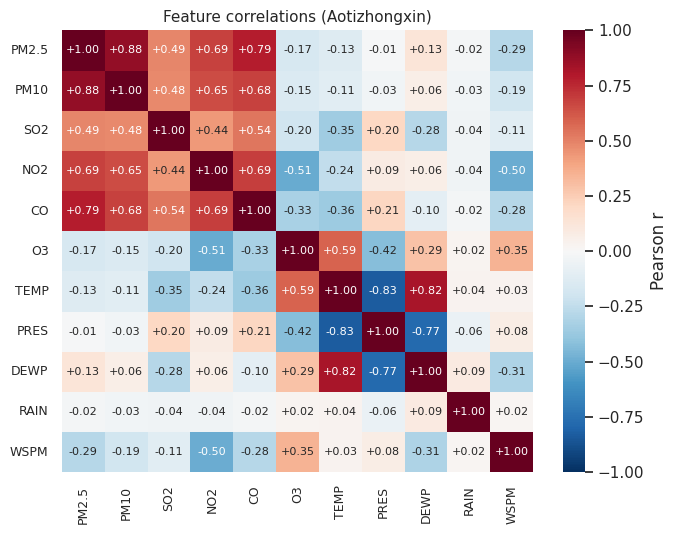

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    X.corr(), annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "Pearson r"},
    annot_kws={"size": 8},
)
ax.tick_params(axis="both", labelsize=9)
ax.set_title("Feature correlations (Aotizhongxin)", fontsize=11)
plt.tight_layout(); plt.show()

Several patterns jump out. The strongest pairs (in decreasing |r|) are typically:

| Pair | **r** | Why they move together |
|---|---|---|
| PM2.5 ↔ PM10 | ≈ +0.88 | Fine and coarse particulates largely share sources (combustion, re-suspended dust). |
| TEMP ↔ PRES  | ≈ &minus;0.83 | Warm air masses are low-pressure (summer); cold high-pressure systems dominate winter. |
| TEMP ↔ DEWP  | ≈ +0.82 | Warmer air can hold more water vapour, so dew point tracks temperature. |
| PM2.5 ↔ CO   | ≈ +0.79 | Canonical "combustion co-tracer" pair — both emitted by traffic and residential burning. |
| PRES ↔ DEWP  | ≈ &minus;0.77 | Same seasonal/synoptic signal as TEMP–PRES. |
| NO₂ ↔ CO  | ≈ +0.69 | Both are products of engines and boilers. |

Broader structure:

- A **"combustion cluster"** of correlated pollutants: PM2.5, PM10, CO, NO₂ (and to a lesser extent SO₂).
- A **"thermodynamic/synoptic cluster"**: TEMP, DEWP positively correlated, both anti-correlated with PRES.
- **O₃ stands apart** — weakly anti-correlated with NO₂ (because NO titrates ozone) and correlated with sunny/windy conditions.
- **RAIN** has almost zero correlation with everything — its sparse, bursty nature hides linear relationships.

The key takeaway for PCA: **many features move together → there is redundancy → PCA will be able to compress**. The two obvious "bundles" (combustion, synoptic) already hint at what the first two principal components will look like.

---
## 6. Standardisation (and why it matters here)

PCA finds directions of **maximum variance**. If one feature has a much larger numeric scale than the others, it will dominate those directions automatically — regardless of whether it actually carries more *information*. Compare typical magnitudes in this dataset:

| Feature | Typical magnitude |
|---|---|
| PRES  | ~1013 hPa |
| CO    | ~1000 µg/m³ |
| PM2.5 | ~80 µg/m³ |
| TEMP  | ~15 °C |
| WSPM  | ~2 m/s  |
| RAIN  | ~0.05 mm |

Without standardisation, whichever feature has the largest variance would hijack the first component — regardless of whether it carries any interesting structure. We fix that with `StandardScaler`: each feature ends up with mean 0 and standard deviation 1, so all features get a fair voice in the PCA. (In Section&nbsp;12 we run PCA without scaling to see this empirically.)

In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sanity check: each column should have mean ~0 and std ~1
pd.DataFrame(X_scaled, columns=FEATURES).agg(["mean", "std"]).round(3)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## 7. How PCA actually works

Principal Component Analysis looks for a new set of orthogonal axes such that:

- the **first axis** (PC1) is the direction along which the data varies the most,
- **PC2** is the direction, orthogonal to PC1, that captures the most *remaining* variance,
- PC3 is the direction orthogonal to both PC1 and PC2 with the most remaining variance,
- and so on.

Mathematically, these directions are the **eigenvectors of the covariance matrix** of the (centred, standardised) data. Their corresponding **eigenvalues** measure how much variance each direction captures.

For our purposes the key working vocabulary is:

| Term | Meaning |
|---|---|
| **Principal component (PC)** | One of the new orthogonal directions (a unit vector in the original feature space). |
| **Score** | The coordinate of a data point along a PC (what `pca.transform(X)` returns). |
| **Loading** | The weight of an original feature in a PC — i.e., an entry of the PC's unit vector. Large absolute loadings tell you *which features define that PC*. |
| **Explained variance ratio** | Fraction of total variance captured by a PC. Sums to 1 across all components. |

> **Important sign caveat.** A PC vector is only defined up to a sign — flipping a PC (and its scores) gives a mathematically equivalent solution. When interpreting loadings, what matters is the *pattern of positive and negative weights relative to each other*, not whether they are positive or negative as a whole.

### Are PC components physical quantities?

**Short answer: no — not inherently.** Principal components are **latent (hidden) variables** constructed by mathematics alone. They are:

- *linear combinations* of the original features,
- chosen to capture as much variance as possible,
- mutually orthogonal.

Symbolically, a component might look like:

$$ \mathrm{PC1} \;=\; 0.42 \cdot \mathrm{CO} \;+\; 0.41 \cdot \mathrm{NO_2} \;+\; 0.38 \cdot \mathrm{PM2.5} \;-\; 0.30 \cdot \mathrm{TEMP} \;+\; \dots $$

That formula is a *statistical* axis, not a physical law. PCA did not consult atmospheric chemistry; it just found the direction of largest variance in the standardised data.

**However — we can often *assign* a physical interpretation after the fact** by looking at which features dominate each component. For example, in air-quality data one typically sees:

| Dominant loadings | Plausible interpretation |
|---|---|
| large positive on NO₂, CO, PM2.5 | combustion pollution (traffic + heating) |
| large on O₃, negative on NO₂  | photochemistry / sunlight |
| SO₂ stands out on its own        | industrial / coal signature |

These are **hypotheses layered on top of the math** — not things PCA proved. A good workflow is:

1. Let PCA surface the components.
2. Look at the loadings and *propose* an interpretation.
3. Cross-check against domain knowledge (rush-hour timing, wind direction, seasonal cycles, known emission sources).

> **Don't assume every PC has a clean physical story.** Some components simply mix multiple processes, or capture statistical patterns without clear physics. A PC with no clean interpretation is still a *valid* statistical axis — it just isn't useful as a physical label.

Later in this notebook we apply exactly this workflow: we read off the loadings, *propose* names for PC1–PC4, and stay honest about where the math ends and the interpretation begins.

---
## 8. The `sklearn.decomposition.PCA` API

The essential workflow is `create → fit → transform`:

```python
pca = PCA(n_components=k)      # k can be int, float (variance fraction), or None
pca.fit(X_scaled)              # learn the PC directions
scores = pca.transform(X_scaled)  # project data into PC space
# or do both at once:
scores = pca.fit_transform(X_scaled)
```

Attributes to know:

| Attribute | Shape | What it is |
|---|---|---|
| `pca.components_` | `(n_components, n_features)` | Each **row** is a PC direction = vector of **loadings**. |
| `pca.explained_variance_ratio_` | `(n_components,)` | Fraction of variance per component. |
| `pca.explained_variance_` | `(n_components,)` | Raw eigenvalues. |
| `pca.mean_` | `(n_features,)` | Feature means subtracted by `fit` (PCA centres automatically). |
| `pca.n_components_` | scalar | Actual number of components kept. |

> **Watch out.** `sklearn`'s `PCA` **does not** standardise features for you — only centring. Scaling is your responsibility (we did it with `StandardScaler` above).

Let's fit PCA on our data, keeping *all* components at first so we can see the full spectrum before deciding how many to keep.

In [7]:
pca = PCA()                   # keep all 11 components
pca.fit(X_scaled)

print(f"components_ shape:        {pca.components_.shape}")
print(f"explained_variance_ratio_ (first 5): {np.round(pca.explained_variance_ratio_[:5], 3)}")
print(f"mean_ (first 5):          {np.round(pca.mean_[:5], 3)}")
print(f"n_components_:            {pca.n_components_}")

components_ shape:        (11, 11)
explained_variance_ratio_ (first 5): [0.376 0.25  0.114 0.091 0.052]
mean_ (first 5):          [ 0.  0.  0.  0. -0.]
n_components_:            11


> **A small puzzle about `mean_`.** You will see `mean_` is essentially a vector of zeros. That is *not* because the raw features had mean zero — PM2.5 averages around 80 µg/m³, PRES around 1013 hPa, etc. It is because we **already centred and scaled** the data with `StandardScaler` before calling `fit`. `PCA.fit` always centres whatever it receives; if the input is already centred, the centre it records is (almost) zero.

If you had skipped `StandardScaler` and called `pca.fit(X)` on the raw data, `pca.mean_` would instead hold the raw feature means (and PC1 would be hijacked by whichever feature has the largest numeric scale — which is why we standardised in the first place).

---
## 9. How many components to keep? The scree plot

Two standard aids:

1. **Scree plot** — bar chart of the explained variance ratio per component. Look for the *elbow* where the bars stop dropping fast.
2. **Cumulative explained variance** — how much total variance is captured by the first *k* components together. Common thresholds: 80%, 90%, or 95%, depending on how much fidelity you need.

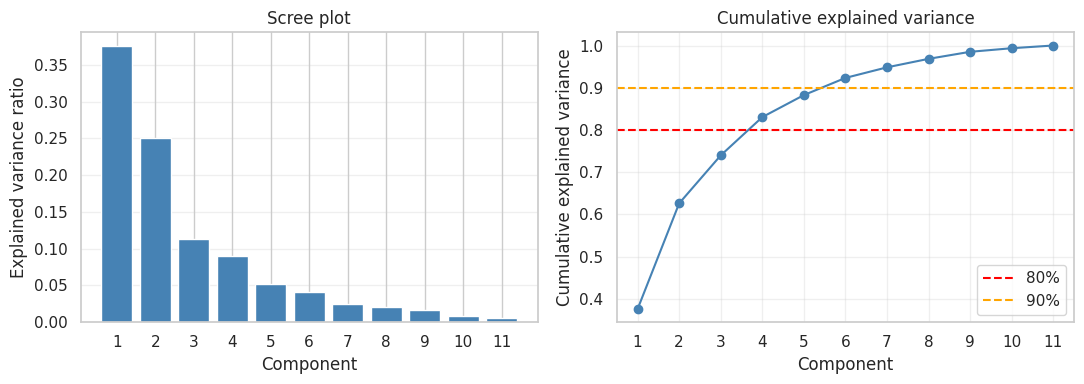

  PC 1:  37.56%   (cumulative 37.56%)
  PC 2:  25.04%   (cumulative 62.61%)
  PC 3:  11.36%   (cumulative 73.97%)
  PC 4:   9.07%   (cumulative 83.04%)
  PC 5:   5.22%   (cumulative 88.25%)
  PC 6:   4.07%   (cumulative 92.32%)
  PC 7:   2.50%   (cumulative 94.83%)
  PC 8:   2.01%   (cumulative 96.84%)
  PC 9:   1.67%   (cumulative 98.51%)
  PC10:   0.85%   (cumulative 99.36%)
  PC11:   0.64%   (cumulative 100.00%)


In [8]:
evr = pca.explained_variance_ratio_
k   = np.arange(1, len(evr) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].bar(k, evr, color="steelblue", edgecolor="white")
ax[0].set_xticks(k)
ax[0].set_xlabel("Component"); ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("Scree plot")
ax[0].grid(axis="y", alpha=0.3)

ax[1].plot(k, evr.cumsum(), "o-", color="steelblue")
ax[1].axhline(0.8, color="red",    linestyle="--", label="80%")
ax[1].axhline(0.9, color="orange", linestyle="--", label="90%")
ax[1].set_xticks(k)
ax[1].set_xlabel("Component"); ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Cumulative explained variance")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Print the numbers for reference
for i, (r, c) in enumerate(zip(evr, evr.cumsum()), start=1):
    print(f"  PC{i:>2}:  {r*100:5.2f}%   (cumulative {c*100:5.2f}%)")

**Reading the plots:**

- There is a clear **elbow after PC4**: the first four components drop steeply, the rest are much smaller and roughly flat.
- Cumulatively, the first four PCs cover about **80% of the total variance**, the first six around 90%.

A reasonable default for downstream work is to **keep 4 components**: we compress 11 features into 4, losing only ~18% of the total variance — and, as we'll see next, each of those 4 has a clear physical interpretation.

### Reconstruction — what does "keeping 4 components" really preserve?

PCA is **reversible**: the transformation from the original space to PC space is a simple rotation, and `pca.inverse_transform` takes us back. If we use all 11 components, the reconstruction is exact. If we keep only *k* components and invert, we get an *approximation* of the original data — and the approximation error is exactly the variance that PCA discarded.

Let's make this concrete: fit PCA with just 4 components, project the data, invert back, and compare to the original.

In [9]:
from sklearn.metrics import r2_score

pca4 = PCA(n_components=4).fit(X_scaled)
X_recon = pca4.inverse_transform(pca4.transform(X_scaled))   # back to 11-dim standardised space

# Per-feature reconstruction quality
r2 = pd.Series(
    {f: r2_score(X_scaled[:, i], X_recon[:, i]) for i, f in enumerate(FEATURES)},
    name="R\u00b2 (4 PCs)",
).sort_values(ascending=False).round(3)

print(f"Total variance preserved: {pca4.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Mean per-feature R\u00b2:    {r2.mean():.3f}\n")
print(r2.to_string())

Total variance preserved: 83.0%
Mean per-feature R²:    0.830

RAIN    1.00
TEMP    0.93
DEWP    0.91
PM2.5   0.89
PM10    0.84
PRES    0.83
NO2     0.82
CO      0.79
WSPM    0.78
O3      0.77
SO2     0.57


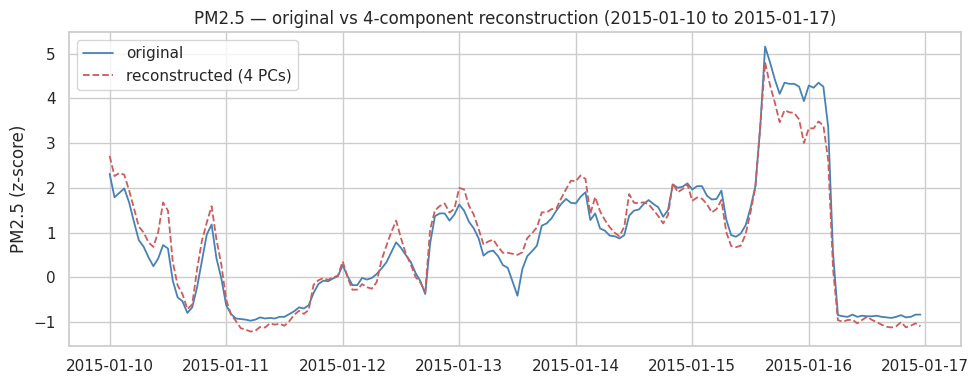

In [10]:
# Visual check: one week of PM2.5 (standardised), original vs reconstructed
i_pm = FEATURES.index("PM2.5")
start = pd.Timestamp("2015-01-10")
week  = (meta["datetime"] >= start) & (meta["datetime"] < start + pd.Timedelta("7d"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(meta.loc[week, "datetime"], X_scaled[week, i_pm],
        label="original", color="steelblue", linewidth=1.3)
ax.plot(meta.loc[week, "datetime"], X_recon[week, i_pm],
        label="reconstructed (4 PCs)", color="indianred", linewidth=1.3, linestyle="--")
ax.set_ylabel("PM2.5 (z-score)")
ax.set_title(f"PM2.5 \u2014 original vs 4-component reconstruction ({start.date()} to {(start + pd.Timedelta('7d')).date()})")
ax.legend(); plt.tight_layout(); plt.show()

Several things are worth noticing:

- **Mean per-feature R² ≈ 0.83** matches almost exactly the cumulative explained variance of 83%. That is not a coincidence: the fraction of variance retained *is* the average reconstruction quality when measured on the standardised features.
- **RAIN reconstructs almost perfectly** (R² ≈ 0.998) because PC4 is dedicated almost entirely to it — we effectively "spent" one of our four axes on RAIN.
- **SO₂ reconstructs worst** (R² ≈ 0.57). Its cleanest signal lives in PC5 and beyond, which we threw away.
- **The PM2.5 time series over one week tracks the broad shape of the original**: peaks, dips, and the smog episode around 15&nbsp;January are all visible. You can also see the reconstruction (red dashed) deviating from the original (blue) on individual hours &mdash; the ≈ 17% of variance we discarded shows up as **smoothed-out fine detail and clipped peaks**. The big-picture story is preserved; sub-hour fluctuations are not.

Practical upshot: "keeping 4 of 11 components" is not an abstract statement. It means we can throw away seven numbers per hour and still recreate the original eleven-variable record with high fidelity for most features — a concrete demonstration of what compression has bought us.

---
## 10. What does each PC mean? Reading the loadings

Each row of `pca.components_` is a PC direction — a vector in the original feature space whose entries are the **loadings**. Large positive or negative loadings tell us which features *define* that component. We visualise PC1–PC4 as a heatmap.

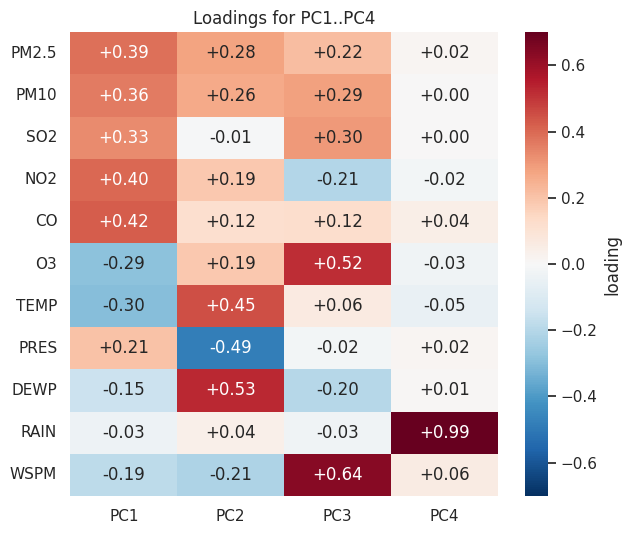

In [11]:
N_SHOW = 4
loadings = pca.components_[:N_SHOW].T   # shape (n_features, N_SHOW)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    loadings, annot=True, fmt="+.2f",
    cmap="RdBu_r", center=0, vmin=-0.7, vmax=0.7,
    yticklabels=FEATURES,
    xticklabels=[f"PC{i+1}" for i in range(N_SHOW)],
    cbar_kws={"label": "loading"}, ax=ax,
)
ax.set_title(f"Loadings for PC1..PC{N_SHOW}")
plt.tight_layout(); plt.show()

Take a moment to read the heatmap *before* scrolling down. Can you propose a physical interpretation for each of PC1..PC4?

<details>
<summary><b>Our interpretation (click to expand)</b></summary>

Quick reference:

| PC | Dominant loadings | Proposed interpretation |
|---|---|---|
| **PC1** | CO, NO₂, PM2.5, PM10, SO₂ strongly positive; TEMP negative | *Combustion pollution* |
| **PC2** | DEWP +, TEMP +, PRES &minus; | *Season / synoptic air mass* |
| **PC3** | WSPM +, O₃ +, (SO₂ small +) | *Dispersion + photochemistry* |
| **PC4** | RAIN alone (~+0.99) | *Rain channel* |

#### PC1 — "combustion pollution" (≈ 38% of variance)

All four major anthropogenic pollutants (CO, NO₂, PM2.5, PM10) line up with large positive loadings, with SO₂ not far behind. TEMP loads negatively. The physical reading is straightforward: **cold hours tend to have high combustion pollution**, because (a) domestic and district heating increase fuel burning, and (b) cold, stable winter air masses trap pollutants near the surface instead of letting them disperse. A high-PC1 hour is a typical Beijing winter smog event; a low-PC1 hour is a warm, clean, well-mixed day.

Note that this component *mixes* emissions and weather — it is not a pure "emissions" axis. PCA only sees covariance: traffic, heating, and stagnation all happen in winter, so they end up on the same axis.

#### PC2 — "season / synoptic air mass" (≈ 25%)

DEWP and TEMP load strongly positively; PRES loads strongly negatively. This is pure thermodynamics of air masses: warm air holds more water (so TEMP and DEWP move together), and synoptic low-pressure systems tend to be warmer than cold high-pressure systems. Summer hours sit on the positive side of PC2, winter hours on the negative side.

The colour-by-season plot later in the notebook is an independent confirmation: PCA was *not* told about any calendar information, yet the seasons sort themselves cleanly along PC2.

#### PC3 — "dispersion + photochemistry" (≈ 11%)

WSPM and O₃ are the two dominant features; everything else is near zero. The mechanism is well-known: strong winds ventilate the boundary layer (so NO, which titrates ozone, gets diluted), and ozone itself is photochemically produced under sunny conditions that often coincide with breezes. SO₂ has a small positive contribution — once the big "everything combustion" signal is absorbed by PC1, the residual SO₂ structure lines up with dispersive conditions. High-PC3 hours are windy, sunny, relatively ozone-rich.

#### PC4 — "rain channel" (≈ 9%)

RAIN has loading ≈ +0.99; every other feature is essentially zero. This is less a *physical* axis and more a **statistical artefact of rain being sparse and bursty**. Most hours have zero rain; a few have a lot. This distribution cannot be absorbed into smoother, continuous signals, so PCA isolates it into its own component. That is perfectly valid — it just tells us "there is one more independent statistical direction in the data, and it's dominated by rain."

---

These interpretations are **hypotheses generated from the math**, not conclusions derived from atmospheric chemistry. They are consistent with known Beijing air-quality dynamics, and the seasonal validation via the month-coloured scatter strengthens them further. Lower-order components (PC5..PC11) could in principle carry additional physics (for example, PC5 is often dominated by SO₂ residuals linked to coal use), but at ~5% of variance each the signal gets weaker and interpretation becomes speculative.
</details>

(If your PC signs come out flipped from the description above, that's fine — PCs are only defined up to a sign. Just read the **pattern** rather than the absolute sign.)

---
## 11. The 2-D projection — rediscovering seasonality

If PC1 is "combustion pollution" and PC2 is "warm vs cold season", we should see a clear seasonal pattern when we plot every hour as a point in the PC1–PC2 plane and colour it by season.

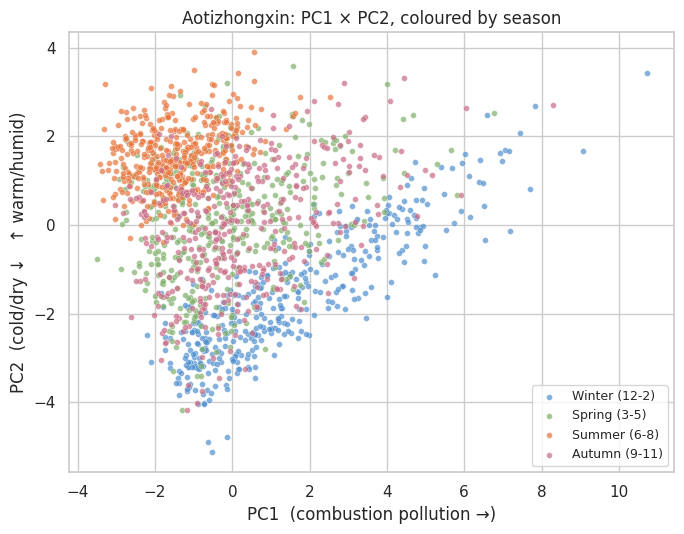

In [12]:
scores = pca.transform(X_scaled)

# Show every 20th hour to keep the scatter readable (~1600 points)
idx = np.arange(0, len(scores), 20)

# Map month to a meteorological season for clearer colour coding
def season_of(m):
    if m in (12, 1, 2):  return "Winter (12-2)"
    if m in (3, 4, 5):   return "Spring (3-5)"
    if m in (6, 7, 8):   return "Summer (6-8)"
    return "Autumn (9-11)"

seasons = meta["month"].apply(season_of).values
palette = {"Winter (12-2)": "#4E8FCE", "Spring (3-5)": "#7FB069",
           "Summer (6-8)": "#E8743B", "Autumn (9-11)": "#C86B85"}
order   = ["Winter (12-2)", "Spring (3-5)", "Summer (6-8)", "Autumn (9-11)"]

fig, ax = plt.subplots(figsize=(7, 5.5))
for s in order:
    m = seasons[idx] == s
    ax.scatter(
        scores[idx][m, 0], scores[idx][m, 1],
        s=18, alpha=0.7, color=palette[s], label=s,
        edgecolor="white", linewidth=0.3,
    )
ax.set_xlabel("PC1  (combustion pollution \u2192)")
ax.set_ylabel("PC2  (cold/dry \u2193   \u2191 warm/humid)")
ax.set_title("Aotizhongxin: PC1 \u00d7 PC2, coloured by season")
ax.legend(loc="lower right", frameon=True, fontsize=9, markerscale=1.0)
plt.tight_layout(); plt.show()

The seasonal structure is striking:

- **Summer (orange)** sits cleanly in the upper-left region — high PC2 (warm, humid) and low PC1 (clean, well-mixed air).
- **Winter (blue)** spreads across the lower-right tail — low PC2 (cold, dry, high-pressure) and the highest PC1 values, the classic Beijing winter smog regime.
- **Spring (green)** and **autumn (pink)** fall between them, acting as transitions.

### Why this result is *genuinely* surprising

Pause and notice what just happened. The PCA input contained **only pollutants and meteorological variables** — no date, no month, no hour, no season. The algorithm has no idea what January is, or that seasons exist. `meta["month"]` was used exclusively to *colour* the scatter **after** PCA was fitted.

Yet a clear annual pattern appears. PCA did not learn seasonality — it learned to describe variance in pollutant + meteorology data, and **the seasonal cycle happens to be the dominant structure in that variance**. That is precisely why colouring the PC scatter by season immediately reveals such clean groups.

This is the core promise of unsupervised learning working in practice: without any labels, and with a purely statistical criterion (maximise variance), we have extracted two axes that carry genuine atmospheric meaning — and an independent variable (month) validates them.

---
## 12. Mini-exercise 1 — what happens if we *don't* standardise?

In Section&nbsp;6 we argued that standardisation is essential — without it, the feature with the largest numeric scale will dominate the principal components. That was the theoretical claim. Let's verify it experimentally.

**Task.** Fit another PCA on the **raw** (non-standardised) feature matrix `X`, keep the original `pca` (trained on `X_scaled`) as reference, and compare:

- how the explained variance is distributed across components, and
- which features dominate PC1.

*Hint — look at `X.std()` first and ask which feature has the largest standard deviation. That is the prime candidate for hijacking PC1 in the unscaled fit.*

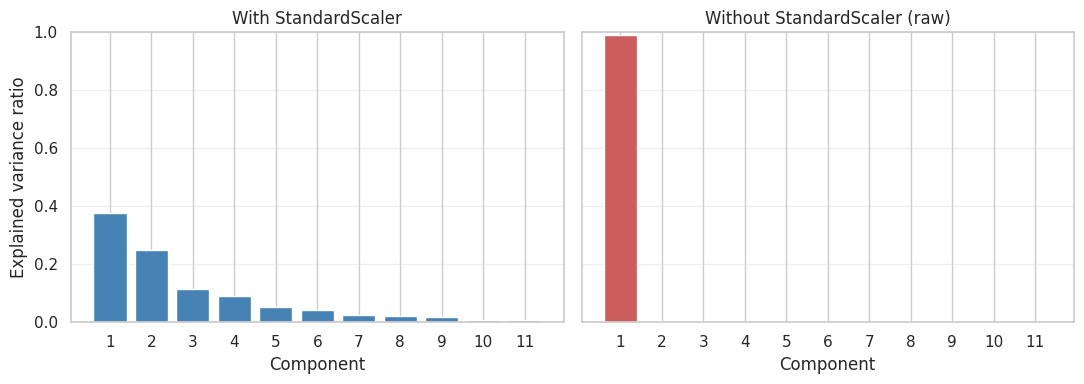

,feature,std(raw),PC1 (scaled),PC1 (raw)
0,PM2.5,80.46,0.39,0.05
1,PM10,93.71,0.36,0.05
2,SO2,22.75,0.33,0.01
3,NO2,37.09,0.40,0.02
4,CO,1223.59,0.42,1.00
5,O3,57.81,-0.29,-0.01
6,TEMP,11.37,-0.30,-0.00
7,PRES,10.34,0.21,0.00
8,DEWP,13.67,-0.15,-0.00
9,RAIN,0.84,-0.04,-0.00


In [13]:
# Fit PCA on raw, non-standardised data (kept: the scaled `pca` from before)
pca_raw = PCA().fit(X)

# --- Compare explained variance side by side ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
k = np.arange(1, len(FEATURES) + 1)

axes[0].bar(k, pca.explained_variance_ratio_,
            color="steelblue", edgecolor="white")
axes[0].set_title("With StandardScaler")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_ylim(0, 1); axes[0].set_xticks(k)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(k, pca_raw.explained_variance_ratio_,
            color="indianred", edgecolor="white")
axes[1].set_title("Without StandardScaler (raw)")
axes[1].set_xlabel("Component")
axes[1].set_ylim(0, 1); axes[1].set_xticks(k)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

# --- PC1 loadings compared ---
pd.DataFrame({
    "feature":    FEATURES,
    "std(raw)":   X.std().round(2).values,
    "PC1 (scaled)": pca.components_[0].round(3),
    "PC1 (raw)":    pca_raw.components_[0].round(3),
})

What you should see:

- **Explained variance collapses onto PC1.** The scaled fit spreads variance sensibly across multiple components (≈38%, 25%, 11%, 9%, …). The raw fit puts essentially everything (**≈99%**) on PC1, and the remaining components are statistical noise (&lt;1% each).
- **PC1 becomes a single-feature detector.** In the raw fit, PC1 has a loading close to **+1.0** on **CO** and near-zero loadings on everything else. CO has by far the largest standard deviation in the raw data (&sigma; ≈ 1200 µg/m³, versus 10 for PRES or &lt;1 for RAIN). Variance scales as &sigma;², so CO alone dominates the total variance budget.
- **The physical story is lost.** The "combustion + heating" interpretation of PC1, the seasonal PC2, the photochemistry PC3 — all gone. PCA is now answering *"which feature has the largest raw variance?"* instead of *"what correlated structure exists in the data?"*.

This is the concrete reason the rule **"always standardise before PCA"** is not a stylistic preference but a methodological requirement. Different features measured in different units have to be put on a level playing field, otherwise the component that "wins" simply tells us which variable the instrument reports in the largest numbers.

---
## 13. Mini-exercise 2 — are the components physical, or specific to Aotizhongxin?

Aotizhongxin is a central-urban station. **Dingling** is a rural station in the mountains north of Beijing — different traffic, different emissions, different exposure to wind.

If our PC interpretations describe *real atmospheric physics*, they should look broadly similar on Dingling. If they are artefacts of one station, the loadings will disagree sharply.

**Task.** Run PCA on Dingling with the same pipeline, then compare loadings side-by-side.

In [14]:
df_d = pd.read_csv("dataset/PRSA_Data_Dingling_20130301-20170228.csv")
X_d  = df_d[FEATURES].dropna()

pca_d = PCA()
pca_d.fit(StandardScaler().fit_transform(X_d))

compare = pd.DataFrame({
    "feature":     FEATURES,
    "Aotiz_PC1":   pca.components_[0].round(3),
    "Dingl_PC1":   pca_d.components_[0].round(3),
    "Aotiz_PC2":   pca.components_[1].round(3),
    "Dingl_PC2":   pca_d.components_[1].round(3),
})
compare

,feature,Aotiz_PC1,Dingl_PC1,Aotiz_PC2,Dingl_PC2
0,PM2.5,0.39,0.38,0.28,0.31
1,PM10,0.36,0.35,0.26,0.30
2,SO2,0.33,0.35,-0.01,0.02
3,NO2,0.40,0.43,0.19,0.14
4,CO,0.42,0.42,0.12,0.18
5,O3,-0.29,-0.25,0.19,0.25
6,TEMP,-0.30,-0.30,0.45,0.44
7,PRES,0.21,0.23,-0.49,-0.47
8,DEWP,-0.15,-0.18,0.53,0.50
9,RAIN,-0.04,-0.03,0.04,0.04


You should see that **the loading patterns are very similar** for PC1 and PC2 (up to an overall sign flip on any component, which is allowed). The combustion-pollution axis and the seasonal axis exist at both stations — they really are physics, not artefacts of a single location.

Small differences in loadings (e.g. how big the CO weight is) reflect the genuine differences between an urban and a rural site — for example, traffic-related pollutants like CO and NO₂ tend to load less heavily at the rural Dingling station, where there is far less local traffic.

---
## Recap

- **Standardise first, always.** Without `StandardScaler`, CO (&sigma; ≈ 1200 µg/m³) alone would hijack PC1 and wipe out the richer structure.
- **PCA found structure without labels.** PC1 = combustion pollution, PC2 = season, PC3 = photochemistry/dispersion, PC4 = rain. Four components capture ~80% of the variance.
- **Loadings are the interpretation.** The sign and magnitude pattern across original features is what turns a PC into a physical story.
- **Signs are arbitrary.** Don't over-interpret whether PC1 is positive or negative overall; read the *relationships* between loadings.
- **PCA is a hypothesis generator.** "PC1 looks like a traffic + heating axis" is a statement to be *tested* against rush-hour timing, wind, seasonal heating patterns — not a conclusion.

### Check your understanding

1. Why was PCA able to compress 11 features into ~4 components with little information loss?
2. You run PCA on raw (unscaled) data and find PC1 is dominated by whichever feature happens to have the largest numeric range. Is this a physical result or an artefact?
3. Your PC1 has CO = &minus;0.42, NO₂ = &minus;0.41, PM2.5 = &minus;0.38 on another dataset. Does this contradict our "combustion pollution" interpretation?

*(Answers: 1 — because the features are highly correlated; many of them carry overlapping information, so a handful of axes suffice. 2 — artefact. The feature with the largest numeric range dominates the variance budget and hijacks PC1; standardise first. 3 — no. PCs are defined up to a sign; flipping the whole component gives the same interpretation.)*

---

### Next up

**Notebook 3 — K-Means clustering on the standardised features.** Having understood what each axis of variability means, we now ask: *how many distinct "pollution regimes" does Beijing experience, and what does each one look like?* The PC1–PC2 map will reappear at the end of NB3 as an independent check that K-Means and PCA agree on the underlying structure.